Dataset Shape: (805549, 9)

Summary Statistics:
             Invoice       Quantity                    InvoiceDate  \
count  805549.000000  805549.000000                         805549   
mean   537410.713358      13.290522  2011-01-02 10:24:44.106814464   
min    489434.000000       1.000000            2009-12-01 07:45:00   
25%    514962.000000       2.000000            2010-07-07 12:08:00   
50%    536989.000000       5.000000            2010-12-03 15:10:00   
75%    561617.000000      12.000000            2011-07-28 13:05:00   
max    581587.000000   80995.000000            2011-12-09 12:50:00   
std     26666.068909     143.634088                            NaN   

               Price     CustomerID     TotalPrice  
count  805549.000000  805549.000000  805549.000000  
mean        3.206561   15331.954970      22.026505  
min         0.001000   12346.000000       0.001000  
25%         1.250000   13982.000000       4.950000  
50%         1.950000   15271.000000      11.850000  
75%

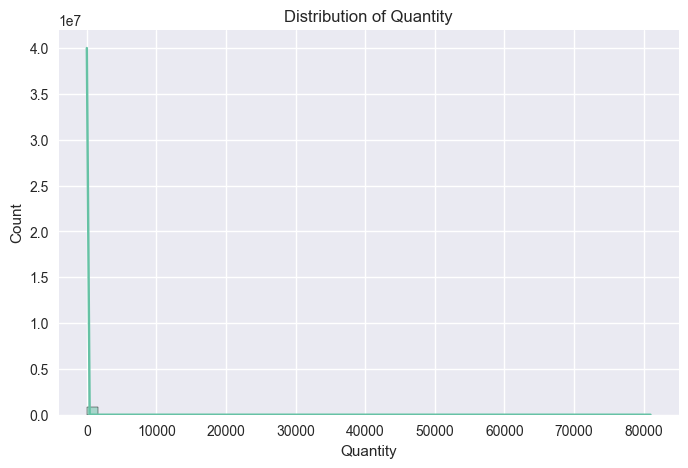

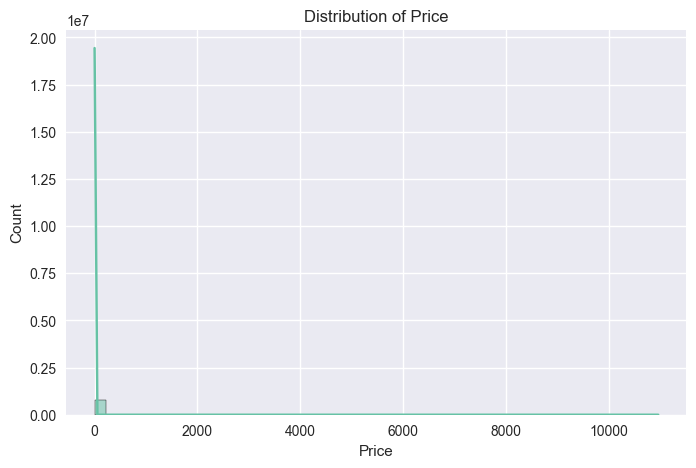

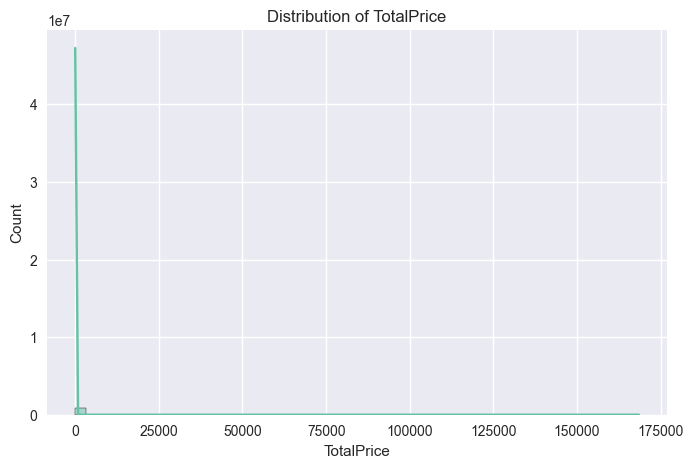

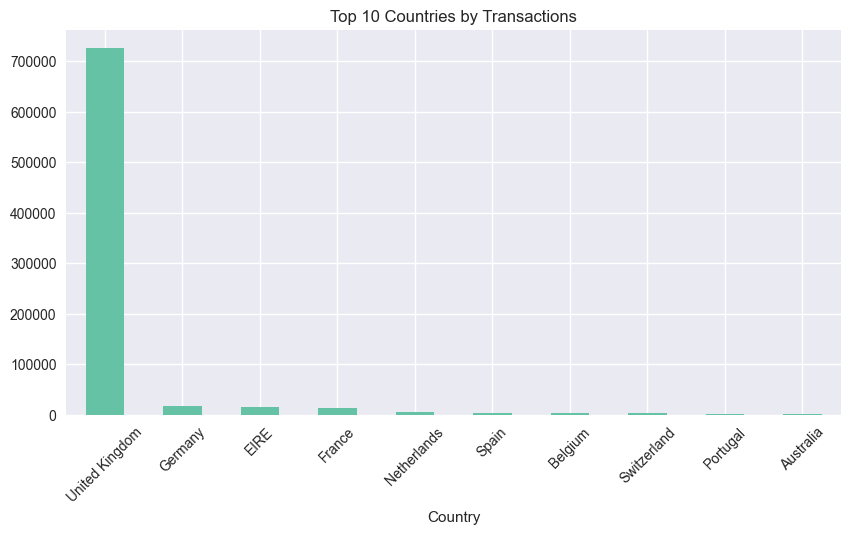

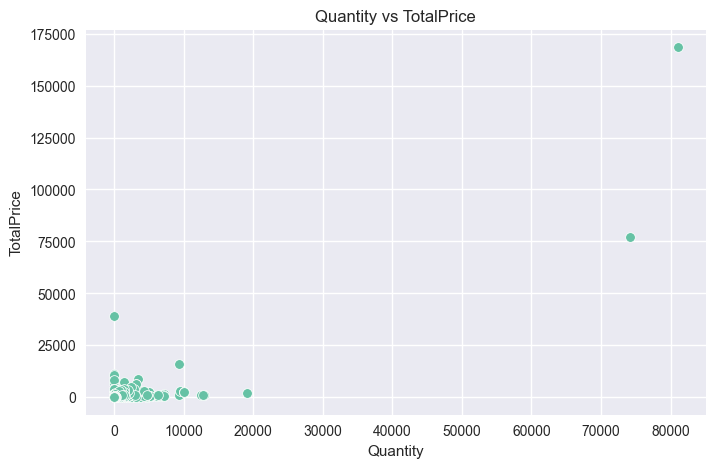

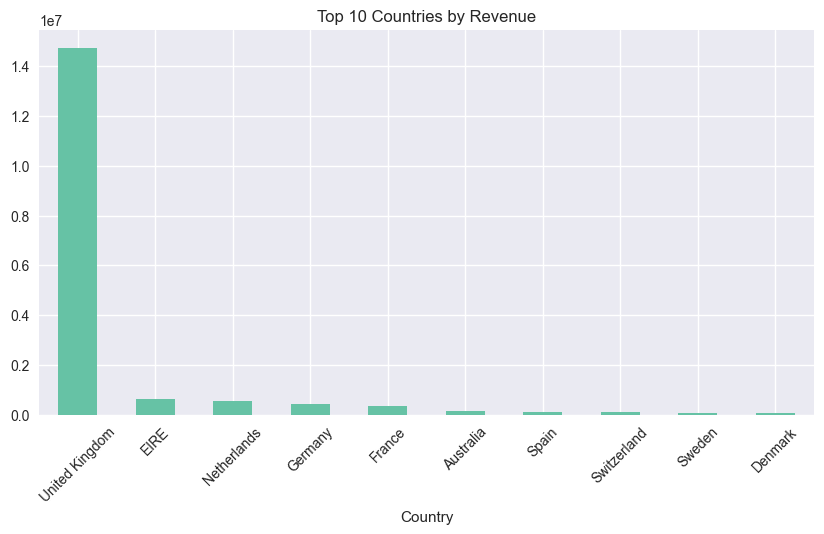

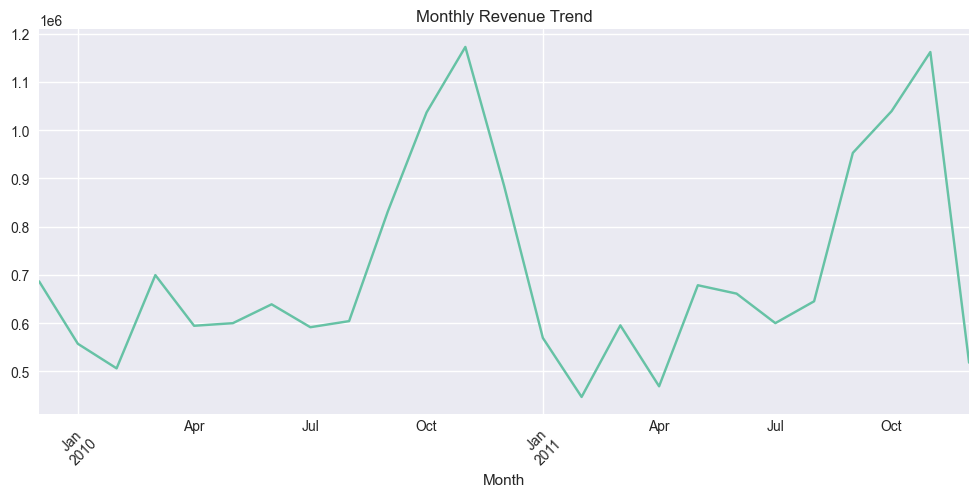

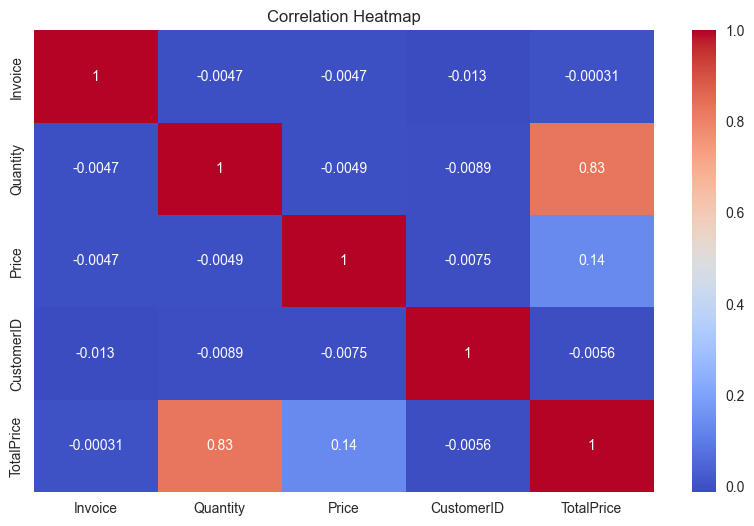

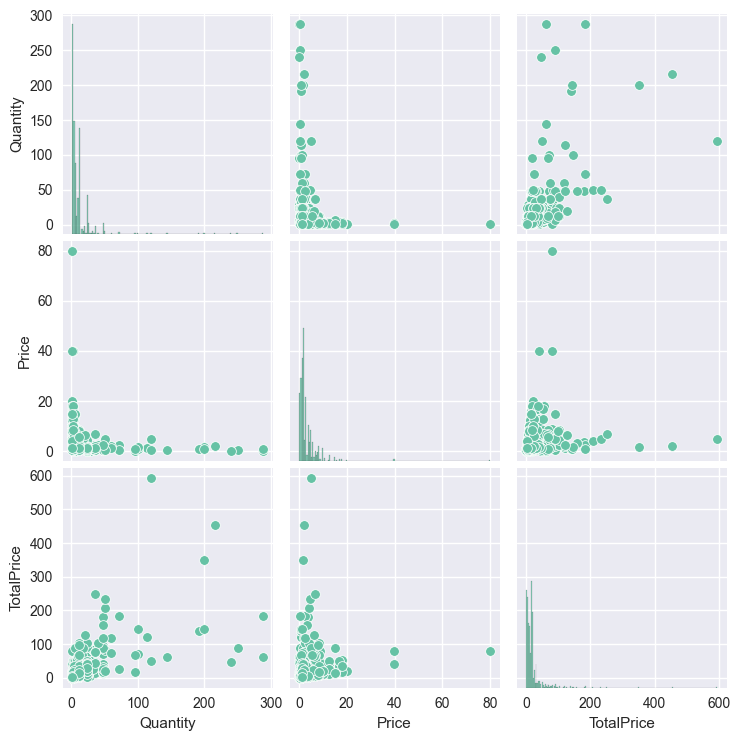


EDA Completed Successfully.


In [4]:
# ==========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# -------------------------------
# 1. Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

# -------------------------------
# 2. Load Cleaned Data
# -------------------------------
df = pd.read_csv("../data/processed/cleaned_data.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Dataset Shape:", df.shape)
df.head()

# -------------------------------
# 3. Basic Statistical Overview
# -------------------------------
print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# UNIVARIATE ANALYSIS
# ==========================================

# Quantity Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Quantity'], bins=50, kde=True)
plt.title("Distribution of Quantity")
plt.show()

# Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title("Distribution of Price")
plt.show()

# Total Revenue Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['TotalPrice'], bins=50, kde=True)
plt.title("Distribution of TotalPrice")
plt.show()

# Top 10 Countries by Transactions
plt.figure(figsize=(10,5))
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries by Transactions")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# BIVARIATE ANALYSIS
# ==========================================

# Quantity vs TotalPrice
plt.figure(figsize=(8,5))
sns.scatterplot(x='Quantity', y='TotalPrice', data=df)
plt.title("Quantity vs TotalPrice")
plt.show()

# Revenue by Country
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
country_revenue.plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# TIME-BASED ANALYSIS
# ==========================================

df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(12,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# MULTIVARIATE ANALYSIS
# ==========================================

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Optional: Pairplot on Sample (to reduce heavy computation)
sample_df = df[['Quantity','Price','TotalPrice']].sample(1000)

sns.pairplot(sample_df)
plt.show()

# ==========================================
# SAVE IMPORTANT SUMMARY (OPTIONAL)
# ==========================================

df.describe().to_csv("../results/eda_summary.csv")

print("\nEDA Completed Successfully.")